# Feature Engineering
## Merging 5 Tables into a Single Dataset

This notebook takes the five raw tables and produces one flat feature matrix for classification.

The raw telemetry is hourly. Failures are sparse. To give the model any useful signal, we need to aggregate sensor readings over time and compute features that carry memory of each machine's recent history.

Feature groups:

| Group | Features | Source |
|-------|----------|--------|
| Daily sensor stats | mean, std, min, max per sensor | telemetry |
| Rolling sensor trends | 3-day and 7-day rolling mean + std | telemetry |
| Error signals | daily error counts per type + 7-day cumulative | errors |
| Maintenance history | days since last maintenance per component | maint |
| Machine metadata | model type (one-hot), age | machines |
| **Target** | **failure within 24 hours? (binary)** | failures |

**Output:** `data/processed/merged_features.csv` with 36,600 rows and 62 features

## 1. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_RAW  = '../data/raw'
DATA_PROC = '../data/processed'
FIG_DIR   = '../figures'
os.makedirs(DATA_PROC, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)

SENSORS = ['volt', 'rotate', 'pressure', 'vibration']

## 2. Load Raw Tables

In [2]:
telemetry   = pd.read_csv(f'{DATA_RAW}/PdM_telemetry.csv', parse_dates=['datetime'])
errors      = pd.read_csv(f'{DATA_RAW}/PdM_errors.csv',    parse_dates=['datetime'])
failures    = pd.read_csv(f'{DATA_RAW}/PdM_failures.csv',  parse_dates=['datetime'])
maintenance = pd.read_csv(f'{DATA_RAW}/PdM_maint.csv',     parse_dates=['datetime'])
machines    = pd.read_csv(f'{DATA_RAW}/PdM_machines.csv')

print('Raw table shapes:')
for name, df in [('telemetry', telemetry), ('errors', errors),
                 ('failures', failures), ('maintenance', maintenance), ('machines', machines)]:
    print(f'  {name:12s}: {df.shape}')

Raw table shapes:
  telemetry   : (876100, 6)
  errors      : (3919, 3)
  failures    : (761, 3)
  maintenance : (3286, 3)
  machines    : (100, 3)


## 3. Step 1 — Daily Telemetry Aggregation

The raw data has 24 readings per machine per day. Individual hourly readings are noisy.
Aggregating to daily stats (mean, std, min, max per sensor) reduces noise while keeping information about the distribution shape.

876,100 hourly rows compress to 36,600 daily rows (100 machines x 366 days).

In [3]:
telemetry['date'] = telemetry['datetime'].dt.normalize()

agg_dict = {s: ['mean', 'std', 'min', 'max'] for s in SENSORS}
daily = telemetry.groupby(['machineID', 'date']).agg(agg_dict)
daily.columns = ['_'.join(col) for col in daily.columns]
daily = daily.reset_index().sort_values(['machineID', 'date'])

print(f'Daily telemetry shape: {daily.shape}')
print(f'Columns: {daily.columns.tolist()}')
display(daily.head(3))

Daily telemetry shape: (36600, 18)
Columns: ['machineID', 'date', 'volt_mean', 'volt_std', 'volt_min', 'volt_max', 'rotate_mean', 'rotate_std', 'rotate_min', 'rotate_max', 'pressure_mean', 'pressure_std', 'pressure_min', 'pressure_max', 'vibration_mean', 'vibration_std', 'vibration_min', 'vibration_max']


,machineID,date,volt_mean,volt_std,volt_min,volt_max,rotate_mean,rotate_std,rotate_min,rotate_max,pressure_mean,pressure_std,pressure_min,pressure_max,vibration_mean,vibration_std,vibration_min,vibration_max
0,1,2015-01-01,167.576533,9.300337,151.335682,182.739113,440.515328,49.590263,346.149335,527.349825,98.522345,10.588562,75.237905,113.077935,40.049623,5.739395,25.990511,51.021486
1,1,2015-01-02,169.795758,15.742155,140.776309,200.872430,446.832666,38.800266,384.645962,519.452812,98.454608,11.679314,78.880780,127.014498,39.271645,5.579524,29.527665,52.355876
2,1,2015-01-03,171.862244,11.182853,154.199258,194.942847,459.204742,47.387959,374.127148,568.972310,97.998233,8.884765,85.246610,116.008404,48.074091,8.194927,32.323616,66.764515


## 4. Step 2 — Rolling Window Features

A single day's reading is not enough to detect gradual degradation. If a machine's rotation speed has been falling for a week, that pattern matters.

We compute 3-day and 7-day rolling statistics on each sensor's daily mean:
- Rolling mean captures the trend direction
- Rolling std captures how stable or erratic that trend has been

In [4]:
mean_cols = [f'{s}_mean' for s in SENSORS]

for window in [3, 7]:
    rolled_mean = (daily.groupby('machineID')[mean_cols]
                   .transform(lambda x: x.rolling(window, min_periods=1).mean()))
    rolled_std  = (daily.groupby('machineID')[mean_cols]
                   .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0)))
    for col in mean_cols:
        daily[f'{col}_rolling{window}']     = rolled_mean[col]
        daily[f'{col}_rolling{window}_std'] = rolled_std[col]

rolling_cols = [c for c in daily.columns if 'rolling' in c]
print(f'Rolling features added: {len(rolling_cols)}')
print(f'Daily shape after rolling features: {daily.shape}')

Rolling features added: 16
Daily shape after rolling features: (36600, 34)


### Rolling features: rotation speed for one machine

The 7-day rolling mean smooths out daily noise and makes multi-day trends visible. The rolling std picks up periods where the machine was running inconsistently.

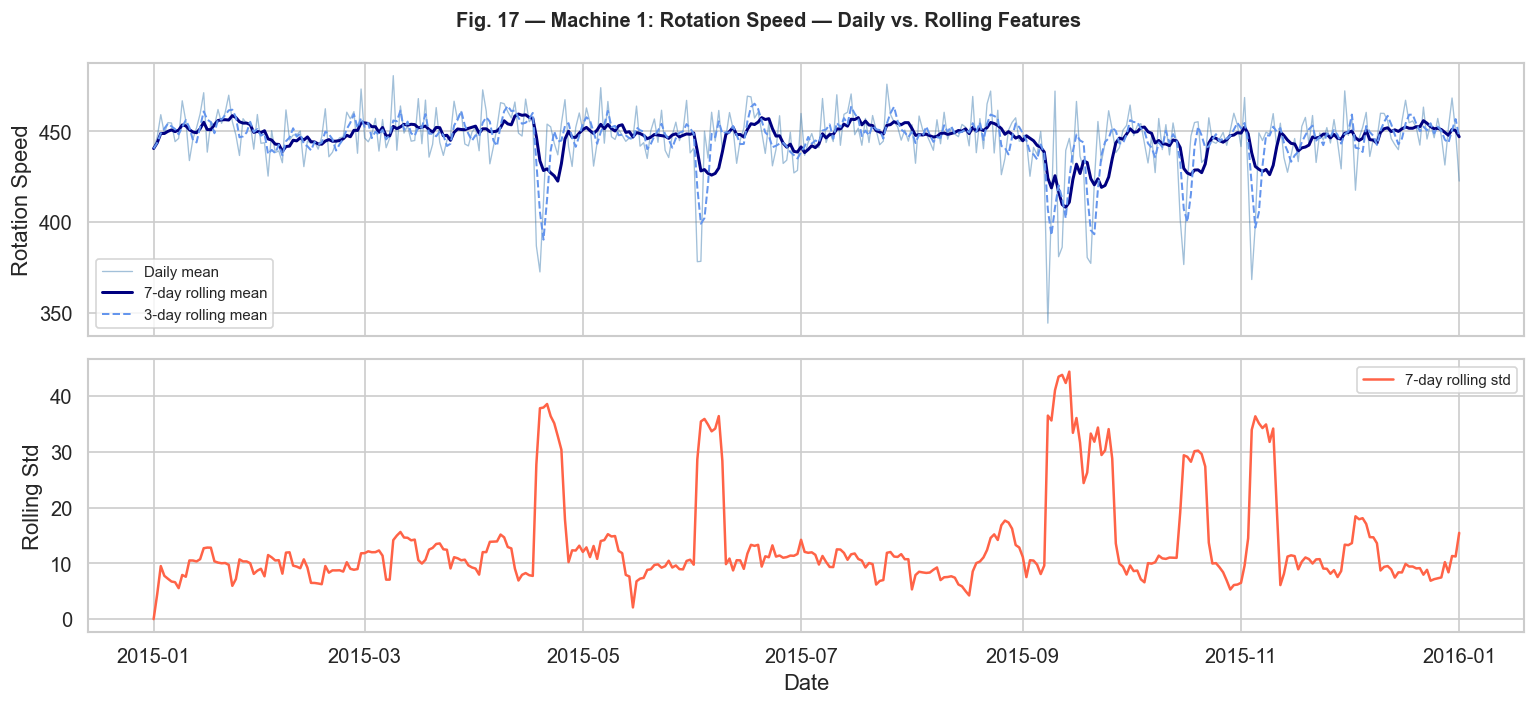

In [5]:
m1 = daily[daily['machineID'] == 1].copy()

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(m1['date'], m1['rotate_mean'], alpha=0.5, linewidth=0.8,
             color='steelblue', label='Daily mean')
axes[0].plot(m1['date'], m1['rotate_mean_rolling7'], linewidth=1.8,
             color='navy', label='7-day rolling mean')
axes[0].plot(m1['date'], m1['rotate_mean_rolling3'], linewidth=1.2,
             color='cornflowerblue', linestyle='--', label='3-day rolling mean')
axes[0].set_ylabel('Rotation Speed')
axes[0].legend(fontsize=9)

axes[1].plot(m1['date'], m1['rotate_mean_rolling7_std'], linewidth=1.5,
             color='tomato', label='7-day rolling std')
axes[1].set_ylabel('Rolling Std')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)

fig.suptitle('Fig. 17 — Machine 1: Rotation Speed — Daily vs. Rolling Features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rolling_features_example.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Step 3 — Error Count Features

Error events tend to cluster before failures. A machine that logged several errors over the past week is in a different state than one that ran without issues.

We compute daily counts by error type (error1 through error5) and a 7-day rolling total.
Days with no errors simply get zeros, not missing values.

In [6]:
errors['date'] = errors['datetime'].dt.normalize()

err_daily = (errors.groupby(['machineID', 'date', 'errorID'])
             .size().unstack(fill_value=0))
err_daily.columns = [f'{c}_count' for c in err_daily.columns]
err_daily = err_daily.reset_index()
err_daily['total_errors'] = err_daily[[c for c in err_daily.columns if '_count' in c]].sum(axis=1)

# 7-day rolling cumulative errors
err_daily = err_daily.sort_values(['machineID', 'date'])
error_base_cols = [c for c in err_daily.columns if '_count' in c or c == 'total_errors']
for col in error_base_cols:
    err_daily[f'{col}_7d'] = (err_daily.groupby('machineID')[col]
                              .transform(lambda x: x.rolling(7, min_periods=1).sum()))

print(f'Error features table shape: {err_daily.shape}')
print(f'Unique (machine, day) combinations with at least one error: {len(err_daily)}')
print(f'Columns: {err_daily.columns.tolist()}')

Error features table shape: (3441, 14)
Unique (machine, day) combinations with at least one error: 3441
Columns: ['machineID', 'date', 'error1_count', 'error2_count', 'error3_count', 'error4_count', 'error5_count', 'total_errors', 'error1_count_7d', 'error2_count_7d', 'error3_count_7d', 'error4_count_7d', 'error5_count_7d', 'total_errors_7d']


## 6. Step 4 — Days Since Last Maintenance

A component that was last serviced 200 days ago is riskier than one that was overhauled last week.
Days since maintenance encodes the component's wear cycle.

For each machine and component, we forward-fill the last recorded maintenance date across the daily grid, then subtract to get elapsed days.

Days before the first recorded maintenance have no history and are filled with -1 (meaning: no maintenance on record yet).

In [7]:
maintenance['date'] = maintenance['datetime'].dt.normalize()

# Full date grid: every machine × every day in the dataset
all_dates = pd.date_range(telemetry['datetime'].min().normalize(),
                          telemetry['datetime'].max().normalize(), freq='D')
grid = pd.MultiIndex.from_product([machines['machineID'].unique(), all_dates],
                                   names=['machineID', 'date'])
grid_df = pd.DataFrame(index=grid).reset_index()

for comp in sorted(maintenance['comp'].unique()):
    comp_dates = (maintenance[maintenance['comp'] == comp][['machineID', 'date']]
                  .drop_duplicates().assign(maint_flag=1))
    grid_df = grid_df.merge(comp_dates, on=['machineID', 'date'], how='left')
    grid_df = grid_df.sort_values(['machineID', 'date'])

    # Forward-fill the maintenance date within each machine group
    grid_df['_last_maint_date'] = grid_df['date'].where(grid_df['maint_flag'] == 1)
    grid_df['_last_maint_date'] = grid_df.groupby('machineID')['_last_maint_date'].ffill()
    grid_df[f'days_since_{comp}'] = (grid_df['date'] - grid_df['_last_maint_date']).dt.days
    grid_df = grid_df.drop(columns=['maint_flag', '_last_maint_date'])

# Fill sentinel value for machines with no maintenance history yet
maint_cols = [c for c in grid_df.columns if 'days_since' in c]
grid_df[maint_cols] = grid_df[maint_cols].fillna(-1)

print(f'Maintenance feature grid shape: {grid_df.shape}')
print(f'days_since_comp1 range: {grid_df["days_since_comp1"].min()} – {grid_df["days_since_comp1"].max()}')
print(f'Sentinel (-1) rows in days_since_comp1: {(grid_df["days_since_comp1"] == -1).sum()}')

Maintenance feature grid shape: (36600, 6)
days_since_comp1 range: -1.0 – 224.0
Sentinel (-1) rows in days_since_comp1: 4845


### Visualise days-since-maintenance for one machine

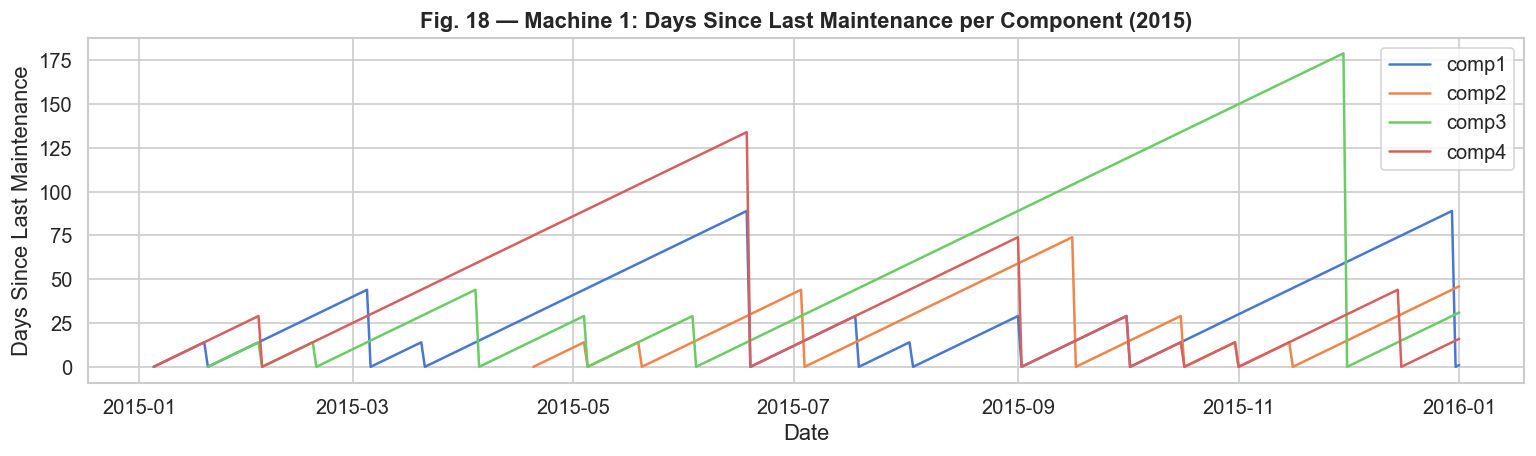

In [8]:
m1_maint = grid_df[grid_df['machineID'] == 1].copy()

fig, ax = plt.subplots(figsize=(13, 4))
palette = sns.color_palette('muted', 4)
for i, comp in enumerate(['comp1', 'comp2', 'comp3', 'comp4']):
    col = f'days_since_{comp}'
    valid = m1_maint[m1_maint[col] >= 0]
    ax.plot(valid['date'], valid[col], linewidth=1.5,
            color=palette[i], label=comp)

ax.set_xlabel('Date')
ax.set_ylabel('Days Since Last Maintenance')
ax.set_title('Fig. 18 — Machine 1: Days Since Last Maintenance per Component (2015)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/days_since_maintenance.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Step 5 — Target Variable

**Prediction problem:** given a machine's sensor readings and error history at the start of day $d$, will it fail on day $d+1$?

A 24-hour window gives maintenance teams enough lead time to act before the failure happens. For each failure event we label the preceding calendar day as positive (target = 1). All other machine-days are negative (target = 0).

In [9]:
failures['date'] = failures['datetime'].dt.normalize()

# Label the day BEFORE the failure as the prediction point
fail_labels = failures[['machineID', 'date', 'failure']].copy()
fail_labels['prediction_date'] = fail_labels['date'] - pd.Timedelta(days=1)

target = (fail_labels.groupby(['machineID', 'prediction_date'])
          .agg(failure_within_24h=('failure', 'count'),
               failure_component=('failure', 'first'))
          .reset_index()
          .rename(columns={'prediction_date': 'date'}))
target['failure_within_24h'] = 1  # all rows here are positives

print(f'Positive labels created: {len(target)}')
print(target.head())

Positive labels created: 718
   machineID       date  failure_within_24h failure_component
0          1 2015-01-04                   1             comp4
1          1 2015-03-05                   1             comp1
2          1 2015-04-19                   1             comp2
3          1 2015-06-18                   1             comp4
4          1 2015-09-01                   1             comp4


## 8. Step 6 — Machine Metadata

Machine model captures design differences between types (e.g., model3 and model4 have no comp3 failures in this dataset).
Age is a simple proxy for cumulative wear. Both are static and joined onto every row for the machine.

In [10]:
machines_enc = pd.get_dummies(machines, columns=['model'], drop_first=False)

# Convert boolean dummies to int for downstream compatibility
bool_cols = machines_enc.select_dtypes(bool).columns
machines_enc[bool_cols] = machines_enc[bool_cols].astype(int)

print('Machine metadata columns after encoding:')
print(machines_enc.columns.tolist())
display(machines_enc.head(3))

Machine metadata columns after encoding:
['machineID', 'age', 'model_model1', 'model_model2', 'model_model3', 'model_model4']


,machineID,age,model_model1,model_model2,model_model3,model_model4
0,1,18,0,0,1,0
1,2,7,0,0,0,1
2,3,8,0,0,1,0


## 9. Step 7 — Merge All Features

All six feature groups are left-joined onto the daily telemetry base on `machineID` and `date`.
This preserves all 36,600 machine-day rows.

In [11]:
df = daily.copy()

# Merge error features (left join — days with no errors get zero-filled)
error_cols = [c for c in err_daily.columns if c not in ['machineID', 'date']]
df = df.merge(err_daily, on=['machineID', 'date'], how='left')
df[error_cols] = df[error_cols].fillna(0)

# Merge maintenance features
df = df.merge(grid_df, on=['machineID', 'date'], how='left')

# Merge machine metadata
df = df.merge(machines_enc, on='machineID', how='left')

# Merge target variable
df = df.merge(
    target[['machineID', 'date', 'failure_within_24h', 'failure_component']],
    on=['machineID', 'date'], how='left'
)
df['failure_within_24h'] = df['failure_within_24h'].fillna(0).astype(int)
df['failure_component']  = df['failure_component'].fillna('none')

print(f'Final merged dataset shape: {df.shape}')
print(f'Feature columns: {df.shape[1] - 3}  (excluding machineID, date, failure_component)')
display(df.head(3))

Final merged dataset shape: (36600, 57)
Feature columns: 54  (excluding machineID, date, failure_component)


,machineID,date,volt_mean,volt_std,volt_min,volt_max,rotate_mean,rotate_std,rotate_min,rotate_max,...,days_since_comp2,days_since_comp3,days_since_comp4,age,model_model1,model_model2,model_model3,model_model4,failure_within_24h,failure_component
0,1,2015-01-01,167.576533,9.300337,151.335682,182.739113,440.515328,49.590263,346.149335,527.349825,...,-1.0,-1.0,-1.0,18,0,0,1,0,0,none
1,1,2015-01-02,169.795758,15.742155,140.776309,200.872430,446.832666,38.800266,384.645962,519.452812,...,-1.0,-1.0,-1.0,18,0,0,1,0,0,none
2,1,2015-01-03,171.862244,11.182853,154.199258,194.942847,459.204742,47.387959,374.127148,568.972310,...,-1.0,-1.0,-1.0,18,0,0,1,0,0,none


## 10. Data Quality Check

In [12]:
print('=== Missing Values ===')
nulls = df.isnull().sum()
if nulls.sum() == 0:
    print('No missing values in the final dataset.')
else:
    print(nulls[nulls > 0].to_string())

print()
print('=== Data Types ===')
print(df.dtypes.value_counts().to_string())

print()
print('=== Target Variable Distribution ===')
counts = df['failure_within_24h'].value_counts()
total  = len(df)
for val, cnt in counts.items():
    label = 'Pre-failure (1)' if val == 1 else 'Normal      (0)'
    print(f'  {label}: {cnt:6,}  ({cnt/total*100:.2f}%)')
print(f'  Imbalance ratio (neg:pos): {counts[0]//counts[1]}:1')

=== Missing Values ===
No missing values in the final dataset.

=== Data Types ===
float64           48
int64              7
datetime64[ns]     1
object             1

=== Target Variable Distribution ===
  Normal      (0): 35,882  (98.04%)
  Pre-failure (1):    718  (1.96%)
  Imbalance ratio (neg:pos): 49:1


## 11. Feature Overview

### 11.1 Descriptive statistics of engineered features

In [13]:
feature_cols = [c for c in df.columns
                if c not in ['machineID', 'date', 'failure_within_24h', 'failure_component']]

print(f'Total features: {len(feature_cols)}')
print()

groups = {
    'Daily sensor stats (16)':   [c for c in feature_cols if any(s in c for s in SENSORS) and 'rolling' not in c],
    'Rolling features (16)':     [c for c in feature_cols if 'rolling' in c],
    'Error counts (12)':         [c for c in feature_cols if 'error' in c or 'Error' in c],
    'Days since maint. (4)':     [c for c in feature_cols if 'days_since' in c],
    'Machine metadata (5)':      [c for c in feature_cols if c in ['age'] or 'model_' in c],
}
for group, cols in groups.items():
    print(f'{group}: {cols}')

Total features: 53

Daily sensor stats (16): ['volt_mean', 'volt_std', 'volt_min', 'volt_max', 'rotate_mean', 'rotate_std', 'rotate_min', 'rotate_max', 'pressure_mean', 'pressure_std', 'pressure_min', 'pressure_max', 'vibration_mean', 'vibration_std', 'vibration_min', 'vibration_max']
Rolling features (16): ['volt_mean_rolling3', 'volt_mean_rolling3_std', 'rotate_mean_rolling3', 'rotate_mean_rolling3_std', 'pressure_mean_rolling3', 'pressure_mean_rolling3_std', 'vibration_mean_rolling3', 'vibration_mean_rolling3_std', 'volt_mean_rolling7', 'volt_mean_rolling7_std', 'rotate_mean_rolling7', 'rotate_mean_rolling7_std', 'pressure_mean_rolling7', 'pressure_mean_rolling7_std', 'vibration_mean_rolling7', 'vibration_mean_rolling7_std']
Error counts (12): ['error1_count', 'error2_count', 'error3_count', 'error4_count', 'error5_count', 'total_errors', 'error1_count_7d', 'error2_count_7d', 'error3_count_7d', 'error4_count_7d', 'error5_count_7d', 'total_errors_7d']
Days since maint. (4): ['days_si

### 11.2 Feature distributions: normal vs. pre-failure

Plotting the same feature split by class is a quick check: if the distributions overlap completely, the feature adds little. Visible separation means the model has something to work with.

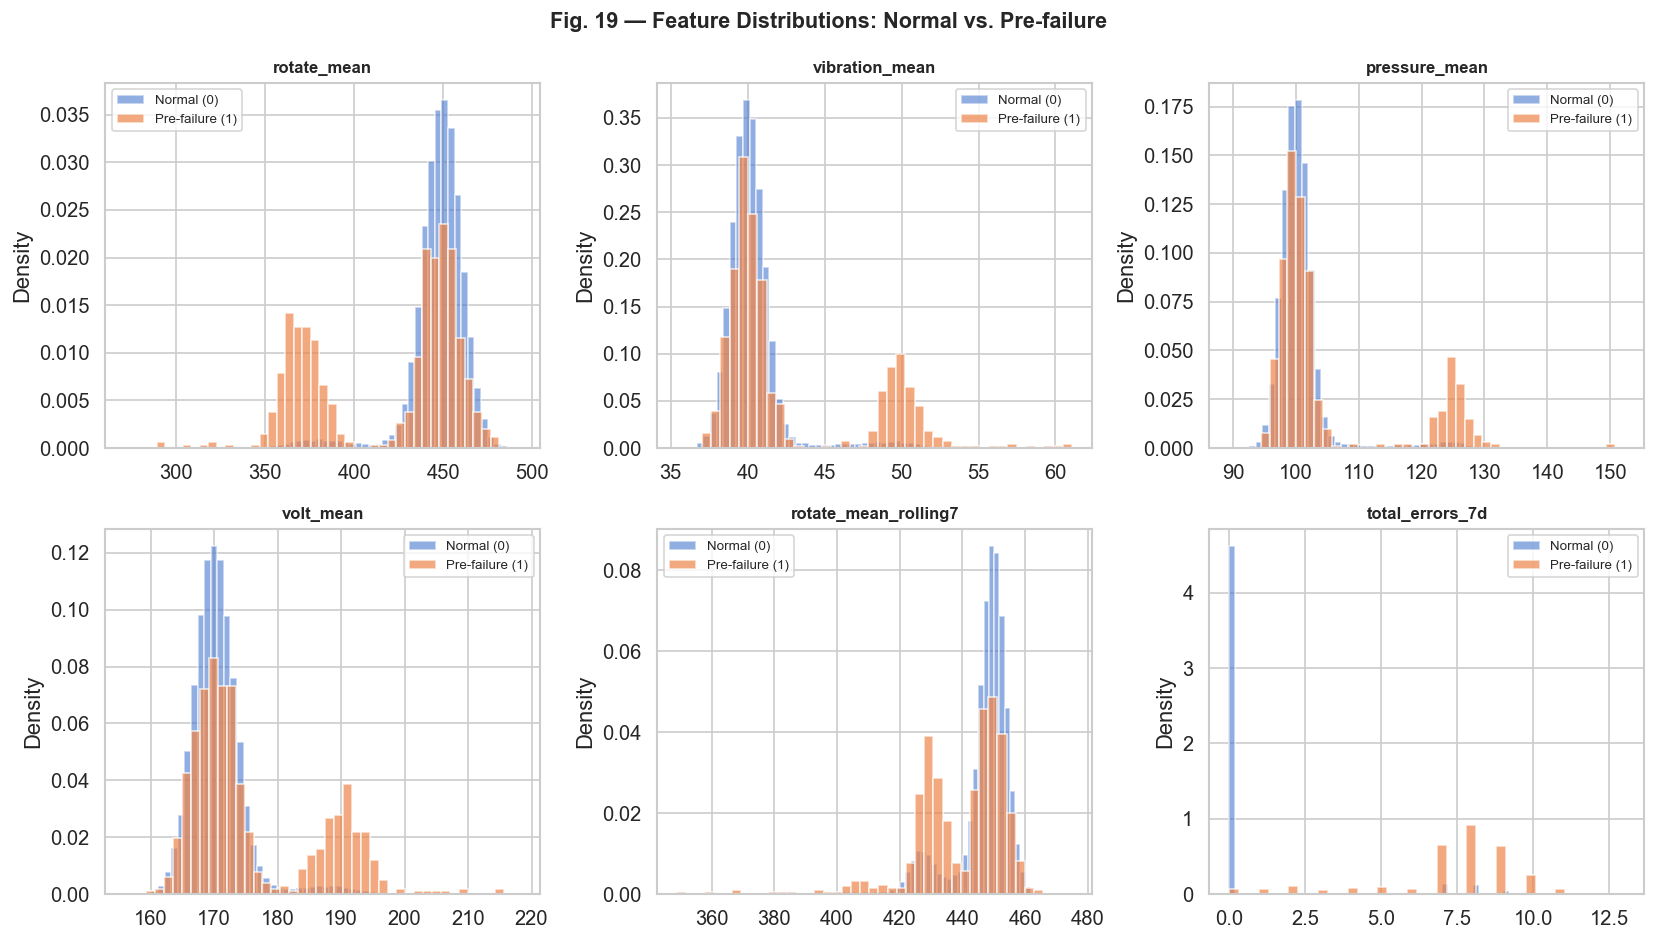

In [14]:
normal    = df[df['failure_within_24h'] == 0]
prefail   = df[df['failure_within_24h'] == 1]

compare_features = ['rotate_mean', 'vibration_mean', 'pressure_mean', 'volt_mean',
                    'rotate_mean_rolling7', 'total_errors_7d']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
palette = sns.color_palette('muted', 2)

for i, feat in enumerate(compare_features):
    axes[i].hist(normal[feat], bins=60, alpha=0.6, color=palette[0],
                 density=True, label='Normal (0)')
    axes[i].hist(prefail[feat], bins=40, alpha=0.7, color=palette[1],
                 density=True, label='Pre-failure (1)')
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Fig. 19 — Feature Distributions: Normal vs. Pre-failure',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/feature_class_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### 11.3 Feature correlation heatmap

Highly correlated features carry the same information. Tree-based models handle this fine, but knowing which features overlap helps interpret results later.

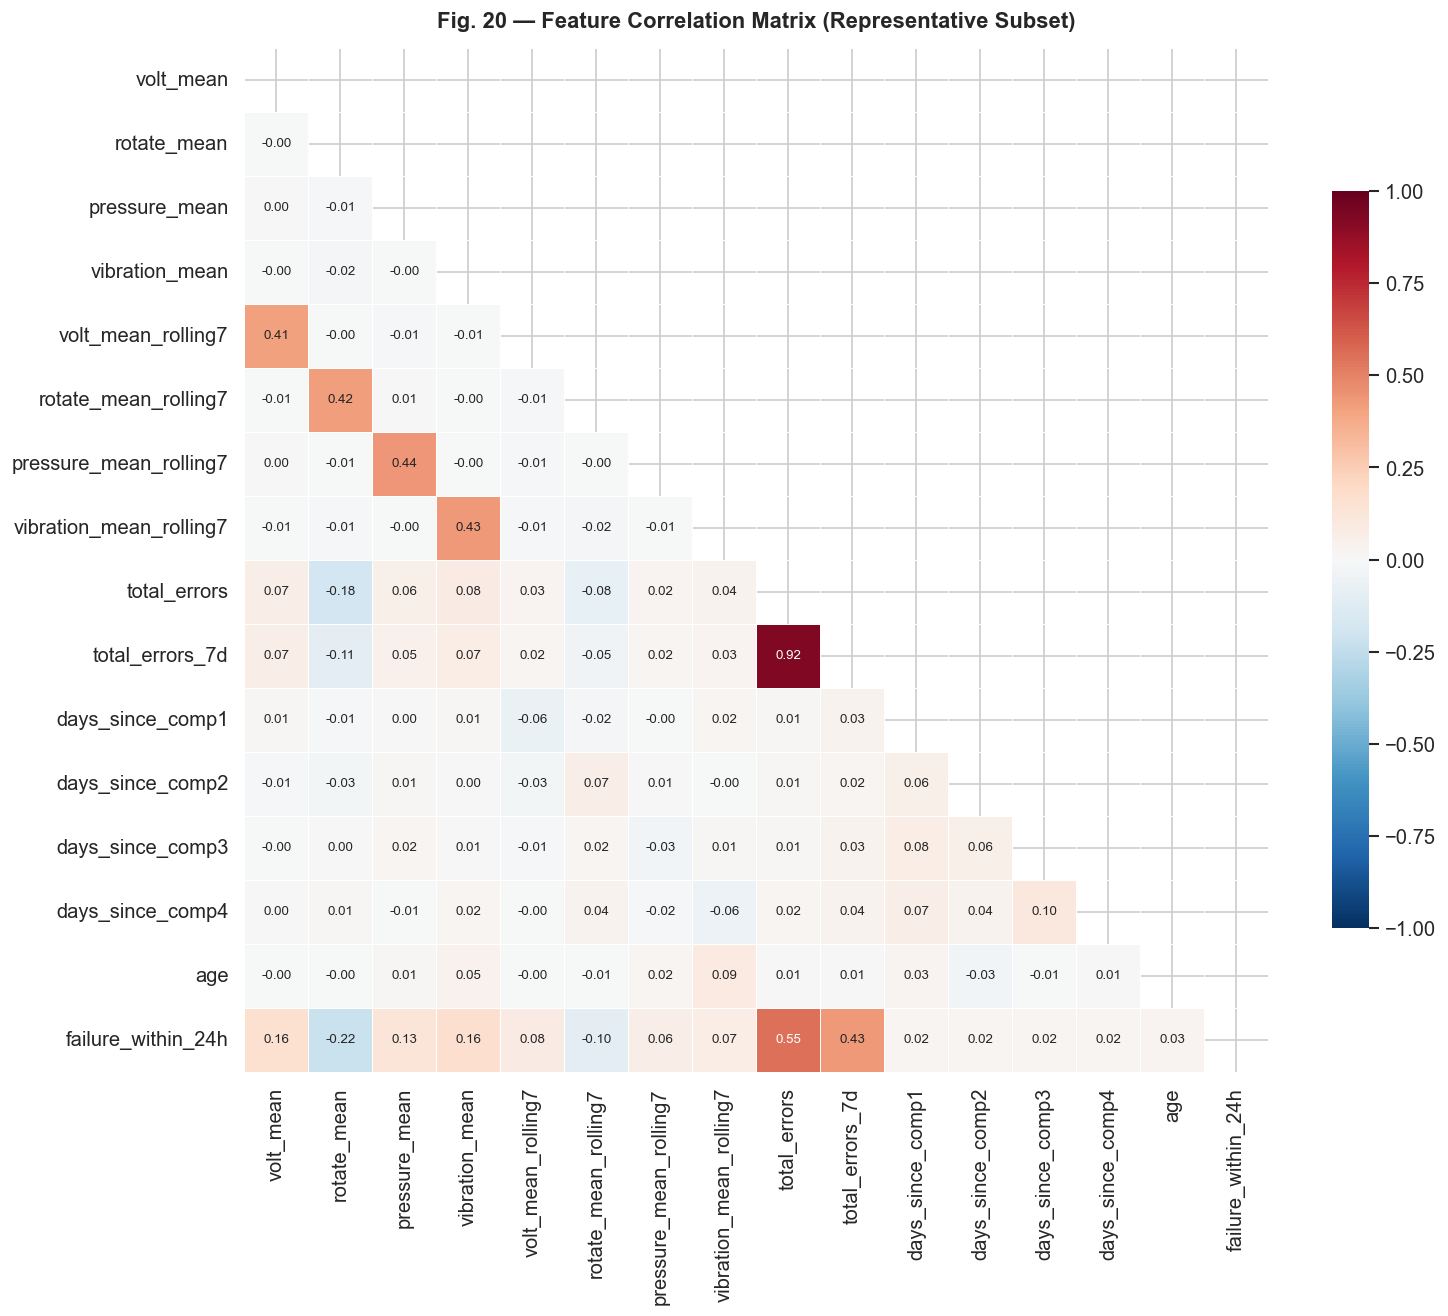

Top 10 features most correlated with target:


,|correlation|
total_errors,0.5512
total_errors_7d,0.4297
rotate_mean,0.2206
vibration_mean,0.1642
volt_mean,0.1573
pressure_mean,0.1325
rotate_mean_rolling7,0.1045
volt_mean_rolling7,0.0833
vibration_mean_rolling7,0.0741
pressure_mean_rolling7,0.0633


In [15]:
# Select a representative subset for readability
representative = (
    [f'{s}_mean' for s in SENSORS] +
    [f'{s}_mean_rolling7' for s in SENSORS] +
    ['total_errors', 'total_errors_7d',
     'days_since_comp1', 'days_since_comp2',
     'days_since_comp3', 'days_since_comp4',
     'age', 'failure_within_24h']
)

corr = df[representative].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, linewidths=0.4, ax=ax,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.7})
ax.set_title('Fig. 20 — Feature Correlation Matrix (Representative Subset)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/feature_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Highlight features with strongest correlation to target
target_corr = corr['failure_within_24h'].drop('failure_within_24h').abs().sort_values(ascending=False)
print('Top 10 features most correlated with target:')
display(target_corr.head(10).round(4).rename('|correlation|').to_frame())

### 11.4 Class distribution in the final dataset

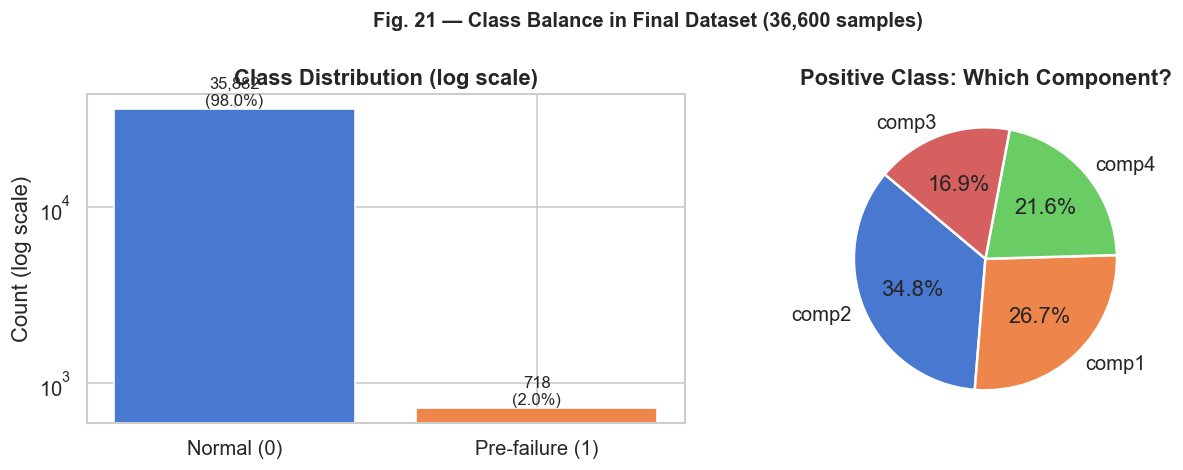

In [16]:
counts = df['failure_within_24h'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

palette_2 = sns.color_palette('muted', 4)
bars = axes[0].bar(['Normal (0)', 'Pre-failure (1)'], counts.values,
                    color=palette_2, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_yscale('log')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Class Distribution (log scale)', fontweight='bold')

# Failure component breakdown
comp_counts = df[df['failure_within_24h'] == 1]['failure_component'].value_counts()
axes[1].pie(comp_counts.values, labels=comp_counts.index,
            colors=sns.color_palette('muted', len(comp_counts)),
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Positive Class: Which Component?', fontweight='bold')

fig.suptitle('Fig. 21 — Class Balance in Final Dataset (36,600 samples)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/final_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Save Processed Dataset

## 11b. Step 8 — Additional Features

### Machine-specific z-scores

A rotation speed of 380 RPM only means something relative to that machine's normal operating range. If machine A normally runs at 450 RPM, a reading of 380 is alarming. If machine B normally runs at 370, it is not.

Comparing against the fleet-wide mean loses this context. Instead, we normalise each sensor reading against that machine's own historical mean and standard deviation across the year.

### Sensor momentum

The direction of change often matters more than the current value. A machine whose rotation speed has been dropping over the past week is behaving differently from one that just happened to record a low reading today.

Momentum = (3-day rolling mean) - (7-day rolling mean). A negative value for rotation speed, for example, means the recent average has fallen below the longer-term baseline.

In [17]:
# --- Machine-specific z-scores ---
# For each machine, compute its own mean and std across the full year,
# then express each daily reading as a deviation from that personal baseline.
for sensor in SENSORS:
    col = f"{sensor}_mean"
    machine_stats = df.groupby("machineID")[col].agg(["mean", "std"])
    machine_stats.columns = [f"_{sensor}_mu", f"_{sensor}_sigma"]
    df = df.merge(machine_stats, on="machineID", how="left")
    # Avoid division by zero for machines with no variance
    sigma = df[f"_{sensor}_sigma"].replace(0, np.nan)
    df[f"{sensor}_zscore"] = (df[col] - df[f"_{sensor}_mu"]) / sigma
    df = df.drop(columns=[f"_{sensor}_mu", f"_{sensor}_sigma"])

# --- Sensor momentum: 3-day trend vs 7-day trend ---
# Positive momentum = short-term mean rising above long-term mean (potential anomaly).
# Negative momentum = short-term mean falling below long-term (degradation signal).
for sensor in SENSORS:
    df[f"{sensor}_momentum"] = (
        df[f"{sensor}_mean_rolling3"] - df[f"{sensor}_mean_rolling7"]
    )

new_feat_cols = ([f"{s}_zscore" for s in SENSORS] +
                 [f"{s}_momentum" for s in SENSORS])
print(f"Added {len(new_feat_cols)} advanced features: {new_feat_cols}")
print(f"Updated dataset shape: {df.shape}")

Added 8 advanced features: ['volt_zscore', 'rotate_zscore', 'pressure_zscore', 'vibration_zscore', 'volt_momentum', 'rotate_momentum', 'pressure_momentum', 'vibration_momentum']
Updated dataset shape: (36600, 65)


In [18]:
# Confirm the new features carry discriminative signal vs the target
advanced_feats = [f"{s}_zscore" for s in SENSORS] + [f"{s}_momentum" for s in SENSORS]
target_corr = (df[advanced_feats + ["failure_within_24h"]]
               .corr()["failure_within_24h"]
               .drop("failure_within_24h")
               .abs()
               .sort_values(ascending=False)
               .round(4)
               .rename("|corr with target|"))
print("Correlation of advanced features with target:")
display(target_corr.to_frame())
print()
print("rotate_zscore is competitive with rotate_mean (the top-correlated raw feature),")
print("while capturing machine-specific deviation rather than fleet-average deviation.")

Correlation of advanced features with target:


,|corr with target|
rotate_zscore,0.2135
volt_zscore,0.1524
vibration_zscore,0.1458
rotate_momentum,0.1407
pressure_zscore,0.1132
vibration_momentum,0.1032
volt_momentum,0.0980
pressure_momentum,0.0834



rotate_zscore is competitive with rotate_mean (the top-correlated raw feature),
while capturing machine-specific deviation rather than fleet-average deviation.


In [19]:
output_path = f'{DATA_PROC}/merged_features.csv'
df.to_csv(output_path, index=False)

file_size_mb = os.path.getsize(output_path) / 1e6
print(f'Saved: {output_path}')
print(f'File size: {file_size_mb:.1f} MB')
print(f'Shape: {df.shape}')

Saved: ../data/processed/merged_features.csv
File size: 30.5 MB
Shape: (36600, 65)


## 13. Feature Engineering Summary

The table below documents every feature group, its rationale, and any caveats for the modelling phase.

In [20]:
summary = pd.DataFrame([
    {'Group':              'Daily sensor stats',
     'Count': 16,
     'Examples':          'volt_mean, rotate_std, pressure_min, vibration_max',
     'Rationale':         'Captures central tendency and spread of hourly sensor readings per day'},

    {'Group':              'Rolling means (3d, 7d)',
     'Count': 8,
     'Examples':          'rotate_mean_rolling7, vibration_mean_rolling3',
     'Rationale':         'Smoothed trend — reduces day-to-day noise and reveals gradual degradation'},

    {'Group':              'Rolling std (3d, 7d)',
     'Count': 8,
     'Examples':          'rotate_mean_rolling7_std, pressure_mean_rolling3_std',
     'Rationale':         'Captures instability / volatility over the recent window'},

    {'Group':              'Daily error counts',
     'Count': 6,
     'Examples':          'error1_count, total_errors',
     'Rationale':         'Error events on the same day as the observation'},

    {'Group':              '7-day cumulative errors',
     'Count': 6,
     'Examples':          'error3_count_7d, total_errors_7d',
     'Rationale':         'Accumulated error pressure over the past week — strong leading indicator'},

    {'Group':              'Days since maintenance',
     'Count': 4,
     'Examples':          'days_since_comp1, days_since_comp4',
     'Rationale':         'Encodes wear cycle; -1 = no prior maintenance recorded'},

    {'Group':              'Machine metadata',
     'Count': 5,
     'Examples':          'age, model_model1, model_model3',
     'Rationale':         'Structural differences between machine types; age as cumulative wear proxy'},

    {'Group':              'TARGET: failure_within_24h',
     'Count': 1,
     'Examples':          '0 = normal, 1 = failure on the following day',
     'Rationale':         '24-hour prediction horizon provides actionable lead time for maintenance'},
])
summary = summary.set_index('Group')
display(summary)

print()
print('=== Key Numbers for the Modelling Notebook ===')
print(f'  Total samples    : {len(df):,}')
print(f'  Total features   : {len(feature_cols)}')
print(f'  Positive samples : {df["failure_within_24h"].sum():,}  ({df["failure_within_24h"].mean()*100:.2f}%)')
print(f'  Negative samples : {(df["failure_within_24h"]==0).sum():,}  ({(df["failure_within_24h"]==0).mean()*100:.2f}%)')
print(f'  Imbalance ratio  : {(df["failure_within_24h"]==0).sum() // df["failure_within_24h"].sum()}:1')
print(f'  Saved to         : data/processed/merged_features.csv')

,Count,Examples,Rationale
Group,,,
Daily sensor stats,16,"volt_mean, rotate_std, pressure_min, vibration...",Captures central tendency and spread of hourly...
"Rolling means (3d, 7d)",8,"rotate_mean_rolling7, vibration_mean_rolling3",Smoothed trend — reduces day-to-day noise and ...
"Rolling std (3d, 7d)",8,"rotate_mean_rolling7_std, pressure_mean_rollin...",Captures instability / volatility over the rec...
Daily error counts,6,"error1_count, total_errors",Error events on the same day as the observation
7-day cumulative errors,6,"error3_count_7d, total_errors_7d",Accumulated error pressure over the past week ...
Days since maintenance,4,"days_since_comp1, days_since_comp4",Encodes wear cycle; -1 = no prior maintenance ...
Machine metadata,5,"age, model_model1, model_model3",Structural differences between machine types; ...
TARGET: failure_within_24h,1,"0 = normal, 1 = failure on the following day",24-hour prediction horizon provides actionable...



=== Key Numbers for the Modelling Notebook ===
  Total samples    : 36,600
  Total features   : 53
  Positive samples : 718  (1.96%)
  Negative samples : 35,882  (98.04%)
  Imbalance ratio  : 49:1
  Saved to         : data/processed/merged_features.csv
